<a href="https://colab.research.google.com/github/abdullahmufeezz/Students_Performance_Analysis_Prediction_System/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Performance Prediction Model**

**1. Importing all Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

**2. Loading and Exploring Dataset (EDA) + Cleaning Data**

In [18]:
df = pd.read_csv("Students_dataset.csv")
df.head(20)   #Checking first 20 values.

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


In [6]:
df.tail(20)   #Checking last 20 Values

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
9980,6,50,8,8,3,78,78.22,Placed
9981,1,53,5,6,12,56,69.62,Not Placed
9982,6,62,6,4,20,55,100.00,Placed
9983,6,92,6,10,18,62,83.24,Placed
9984,6,55,8,8,15,83,100.00,Placed
9985,8,89,9,3,12,68,100.00,Placed
9986,6,60,5,4,4,50,68.45,Not Placed
9987,5,94,7,11,11,45,86.61,Placed
9988,11,94,6,9,6,67,100.00,Placed
9989,2,43,7,5,8,78,100.00,Placed


In [19]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [20]:
df.isnull().sum()  #Checking Null values
df.dropna()        #Removing all null values if any
df = df.drop_duplicates()       #Removing all duplicate values

**3. Features and Target**

In [21]:
# X are your input Features.
X = df[['study_hours',
        'attendance',
        'sleep_hours',
        'internet_usage',
        'assignments_completed',
        'previous_score']]

# Y is your output target.
y = df['exam_score']

**4. Train Test-Split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 20% for testing and 80% for training.
    random_state=42
)

**5. Training Model**

In [23]:
model = RandomForestRegressor(
    n_estimators=100,    #Training on 100 trees, More trees More accurate prediction,But Slow Training.
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**6. Predictions & Evaluation**

In [24]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

MAE  : 5.89
MSE  : 66.05
RMSE : 8.13
R²   : 0.71


**7. Saving the Model**

In [25]:
joblib.dump(model, "model.pkl")

['model.pkl']

**8. Checking Prediction Model for Student Score**

In [31]:
new_student = pd.DataFrame({
    'study_hours': [7],
    'attendance': [85],
    'sleep_hours': [7],
    'internet_usage': [4],
    'assignments_completed': [8],
    'previous_score': [72]
})

predicted_score = model.predict(new_student)

if (predicted_score >= 70):
  print("Placement Done!!")
else:
    print("No placement!!")

print("Predicted Exam Score:", round(predicted_score[0], 2))

Placement Done!!
Predicted Exam Score: 95.8


**9. To Download my Model (model.pkl)**

In [ ]:
#To Download model run this.
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**10. Study Hours vs Exam Score**

This Scatterplot is showing the relation between your Study hours and Exam Score with sample of 50 values.


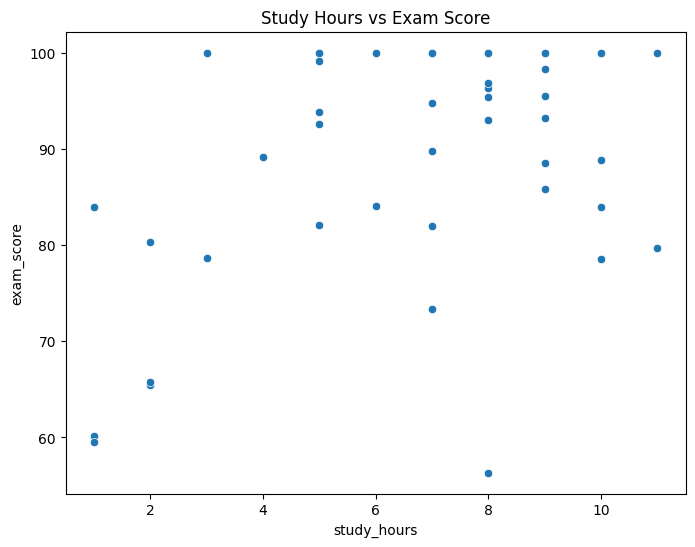

In [14]:
sample_df = df.sample(50, random_state=42)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sample_df,
    x="study_hours",
    y="exam_score"
)
plt.title("Study Hours vs Exam Score")
plt.show()

**11. Correlation Heatmap**

This is showing how each Feature is effecting the exam Score.

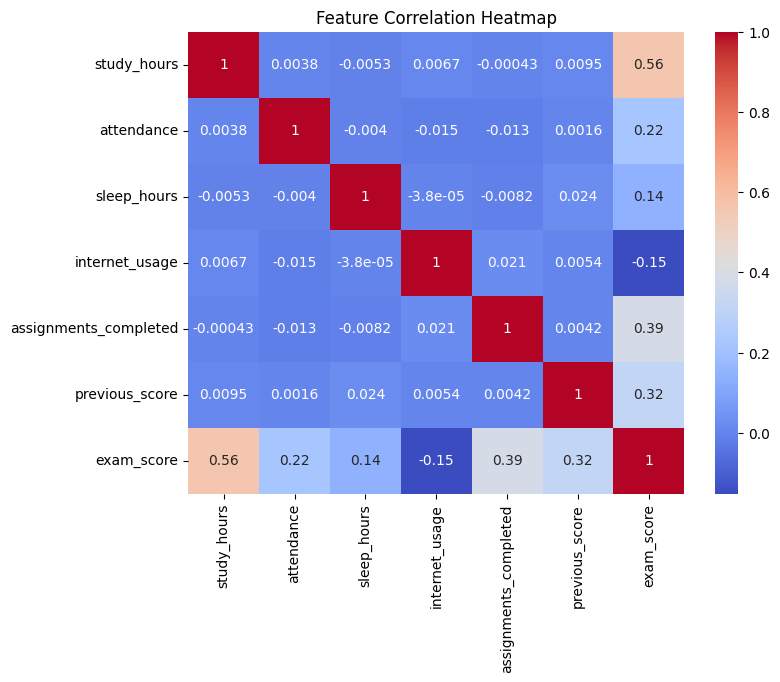

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

**12. Feature Importance Graph**

This graph is showing the improtance of each feature to Predict the Exam Score.

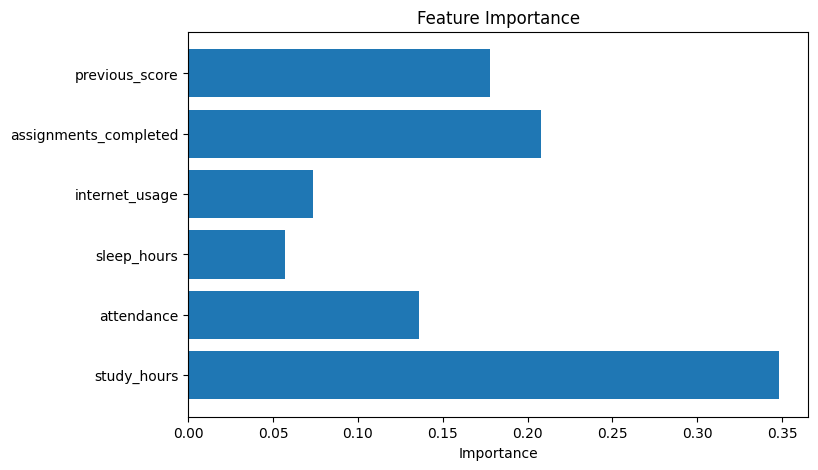

In [26]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()